# Geohash Cover for the United States (Bay Area / Oakland Focus)

This notebook builds a full geohash tiling of the United States, using **two different
precisions** depending on how close a location is to the East Bay:

| Geography                                              | Geohash precision |
|---------------------------------------------------------|:---:|
| Oakland                                                  | 6 |
| Rest of the East Bay (Alameda + Contra Costa, minus Oakland) | 6 |
| San Francisco                                            | 6 |
| Rest of the Bay Area (Marin, Napa, San Mateo, Santa Clara, Solano, Sonoma) | 6 |
| Rest of California                                       | 4 |
| Rest of the United States                                | 4 |

The four "level 6" geographies are mutually exclusive and together tile the entire Bay Area
exactly once. The two "level 4" geographies (rest of California, rest of the US) are gridded
independently of the Bay Area, so a level-4 cell that straddles the Bay Area boundary can
legitimately show up alongside level-6 cells that already cover part of the same physical
space -- this is expected and only happens at the edge of the Bay Area (see Section 7).

Outputs are written to `data/geo/geohash/`:
- `geohash_level6_bay_area.csv` -- one row per level-6 geohash, labeled with its geography
- `geohash_level4_rest_of_state_country.csv` -- one row per level-4 geohash, labeled with its
  geography (a cell can appear here even if it overlaps a level-6 area, as noted above)


## Code Cell 1 -- Imports

All imports used anywhere in the notebook are collected here.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import pygeohash as pgh
from shapely.geometry import box
import matplotlib.pyplot as plt

from tqdm.auto import tqdm


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Code Cell 2 -- Paths and Configurable Constants

Every path, county grouping, and tunable parameter used in the notebook lives here.

In [2]:
# ---------------------------------------------------------------------------
# Source data paths (read-only -- never written to)
# ---------------------------------------------------------------------------
ROOT = Path("/home/aniket/Programming/eddit-east-bay")

CA_COUNTIES_PATH = ROOT / "data/geo/ca_counties2.gpkg"
OAKLAND_PATH = ROOT / "data/geo/oakland_boundary.gpkg"
US_NATION_PATH = ROOT / "data/geo/cb_2018_us_nation_5m"
OAK_BIDS_PATH = ROOT / "data/corridors/OAK_BIDs"

# ---------------------------------------------------------------------------
# Output locations
# ---------------------------------------------------------------------------
OUTPUT_DIR = ROOT / "data/geo/geohash"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LEVEL6_OUTPUT_PATH = OUTPUT_DIR / "geohash_level6_bay_area.csv"
LEVEL4_OUTPUT_PATH = OUTPUT_DIR / "geohash_level4_rest_of_state_country.csv"

CORRIDORS_OUTPUT_DIR = ROOT / "data/corridors/geohash"
CORRIDORS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LEVEL9_CORRIDORS_OUTPUT_PATH = CORRIDORS_OUTPUT_DIR / "geohash_level9_oak_bids.csv"

# ---------------------------------------------------------------------------
# CRS -- geohashes are defined in WGS84 lat/lon, so every input is reprojected
# to this CRS before any gridding happens.
# ---------------------------------------------------------------------------
WGS84 = "EPSG:4326"

# ---------------------------------------------------------------------------
# County groupings (county names match the `CDTFA_COUNTY` field in
# ca_counties2.gpkg, e.g. "Alameda County")
# ---------------------------------------------------------------------------
SF_COUNTY = "San Francisco County"

EAST_BAY_COUNTIES = [
    "Alameda County",
    "Contra Costa County",
]

BAY_AREA_COUNTIES = [
    "Alameda County",
    "Contra Costa County",
    "Marin County",
    "Napa County",
    "San Mateo County",
    "Santa Clara County",
    "Solano County",
    "Sonoma County",
    "San Francisco County",
]

# ---------------------------------------------------------------------------
# Geohash precisions
# ---------------------------------------------------------------------------
GEOHASH_PRECISION_FINE = 6      # Oakland / rest of East Bay / SF / rest of Bay Area
GEOHASH_PRECISION_COARSE = 4    # rest of California / rest of US
GEOHASH_PRECISION_CORRIDOR = 9  # Oakland business corridors (BIDs)

# How many extra rings of geohash cells to grid around a polygon's bounding
# box, to make sure cells that straddle the boundary are never missed.
GRID_BUFFER_CELLS = 1

# A level-4 cell is only kept if at least this fraction of its area overlaps
# the target land region -- this drops cells that are almost entirely ocean,
# while still keeping cells that only partially overlap (e.g. coastline, or
# the edge of the Bay Area).
MIN_LEVEL4_OVERLAP_FRACTION = 0.01

# A level-9 corridor cell is only kept if at least this fraction of its area
# overlaps the corridor polygon.
MIN_CORRIDOR_COVERAGE_FRACTION = 0.8

# ---------------------------------------------------------------------------
# Simplification tolerances (degrees). The source county/nation boundaries
# are far more detailed than we need -- e.g. the 9-county Bay Area union has
# ~150k vertices, which makes every union/difference/spatial-join step
# needlessly slow. We simplify before doing any geometric work, using a
# tolerance well below the size of the geohash cells that will use each
# geometry, so the simplification cannot change which cell a boundary falls
# into.
#   - fine:   ~11m,  used for the level-6 Bay Area layers (cells are ~600m-1km)
#   - coarse: ~110m, used for the level-4 CA/US layers (cells are ~20-30km)
# ---------------------------------------------------------------------------
SIMPLIFY_TOL_FINE = 0.0001
SIMPLIFY_TOL_COARSE = 0.001


# Section 1 -- Load Input Data

**Question:** what geographies do we actually have to build the six-way geohash
classification from?

We have three source files:
- `ca_counties2.gpkg` -- one polygon per California county (58 rows), used both to build the
  Bay Area county groupings and to derive "the rest of California" as the state boundary minus
  the Bay Area.
- `oakland_boundary.gpkg` -- a single polygon for the Oakland city limits.
- `cb_2018_us_nation_5m` -- a single (multi-)polygon covering the entire United States,
  including Alaska, Hawaii, and offshore territories, used to derive "the rest of the US" as
  the national boundary minus California.

Everything is reprojected to WGS84 (EPSG:4326), since geohashes are defined directly in
latitude/longitude.

In [3]:
county_gdf = gpd.read_file(CA_COUNTIES_PATH).to_crs(WGS84)
oakland_gdf = gpd.read_file(OAKLAND_PATH).to_crs(WGS84)
nation_gdf = gpd.read_file(US_NATION_PATH).to_crs(WGS84)

print(f"CA counties: {len(county_gdf)} features, reprojected to {county_gdf.crs}")
print(f"Oakland boundary: {len(oakland_gdf)} feature(s)")
print(f"US nation boundary: {len(nation_gdf)} feature(s)")

missing = set(BAY_AREA_COUNTIES) - set(county_gdf["CDTFA_COUNTY"])
assert not missing, f"Bay Area counties not found in county_gdf: {missing}"


CA counties: 58 features, reprojected to EPSG:4326
Oakland boundary: 1 feature(s)
US nation boundary: 1 feature(s)


# Section 2 -- Build the Four Mutually Exclusive Bay Area Geographies (level 6)

We build these by successive `difference()` calls so that the four geographies never overlap
and their union is exactly the nine-county Bay Area:

1. **Oakland** -- the city limits polygon, as-is.
2. **Rest of East Bay** -- Alameda + Contra Costa counties, minus Oakland.
3. **San Francisco** -- the county polygon, as-is (city and county are coextensive).
4. **Rest of Bay Area** -- the remaining seven Bay Area counties* minus the East Bay and minus
   San Francisco.

\* Marin, Napa, San Mateo, Santa Clara, Solano, Sonoma, plus San Francisco -- San Francisco is
subtracted out separately since it gets its own geography.

Geometries are simplified (at `SIMPLIFY_TOL_FINE`) before any union/difference, which turns a
lengthy, slow set of vertex-heavy operations into a near-instant one without materially
changing the boundary at the ~1km scale of a level-6 geohash cell.

In [4]:
county_fine = county_gdf.copy()
county_fine["geometry"] = county_fine.geometry.simplify(SIMPLIFY_TOL_FINE, preserve_topology=True)

oakland_fine = oakland_gdf.copy()
oakland_fine["geometry"] = oakland_fine.geometry.simplify(SIMPLIFY_TOL_FINE, preserve_topology=True)

oakland_geom = oakland_fine.geometry.union_all()

bay_area_geom = county_fine.loc[county_fine["CDTFA_COUNTY"].isin(BAY_AREA_COUNTIES), "geometry"].union_all()
east_bay_geom = county_fine.loc[county_fine["CDTFA_COUNTY"].isin(EAST_BAY_COUNTIES), "geometry"].union_all()
sf_geom = county_fine.loc[county_fine["CDTFA_COUNTY"] == SF_COUNTY, "geometry"].union_all()

rest_of_east_bay_geom = east_bay_geom.difference(oakland_geom)
rest_of_bay_area_geom = bay_area_geom.difference(east_bay_geom).difference(sf_geom)

level6_layers = {
    "Oakland": oakland_geom,
    "Rest of East Bay": rest_of_east_bay_geom,
    "San Francisco": sf_geom,
    "Rest of Bay Area": rest_of_bay_area_geom,
}

# Sanity check: the four pieces should partition the Bay Area exactly (areas
# in degrees^2, so this is only a relative check, not a real-world unit).
total_parts_area = sum(g.area for g in level6_layers.values())
print(f"Bay Area area:        {bay_area_geom.area:.6f}")
print(f"Sum of 4 parts area:  {total_parts_area:.6f}")
print(f"Relative difference:  {abs(total_parts_area - bay_area_geom.area) / bay_area_geom.area:.2%}")


Bay Area area:        1.876360
Sum of 4 parts area:  1.876362
Relative difference:  0.00%


# Section 3 -- Build "Rest of California" and "Rest of US" Geographies (level 4)

- **Rest of California** = the full California state boundary (union of all 58 counties) minus
  the nine-county Bay Area.
- **Rest of US** = the full national boundary minus California.

These two are gridded independently in Section 7, at the coarser `SIMPLIFY_TOL_COARSE`
tolerance (still ~150x finer than a level-4 cell). Because "rest of California" is only
subtracted from the Bay Area (not from Oakland/East Bay/SF individually), a level-4 cell that
straddles the Bay Area edge will naturally still show up here for the sliver of it that falls
outside the Bay Area -- this is the "semi-duplicate" behavior described in the notebook intro,
and it only happens at the edge of the Bay Area.

In [5]:
county_coarse = county_gdf.copy()
county_coarse["geometry"] = county_coarse.geometry.simplify(SIMPLIFY_TOL_COARSE, preserve_topology=True)

nation_coarse = nation_gdf.copy()
nation_coarse["geometry"] = nation_coarse.geometry.simplify(SIMPLIFY_TOL_COARSE, preserve_topology=True)

ca_geom = county_coarse.geometry.union_all()
us_geom = nation_coarse.geometry.union_all()

# Subtract the (finely simplified) Bay Area boundary from California so the
# level-4 cover lines up with the level-6 cover's edge as closely as possible.
rest_of_california_geom = ca_geom.difference(bay_area_geom)
rest_of_us_geom = us_geom.difference(ca_geom)

level4_layers = {
    "Rest of California": rest_of_california_geom,
    "Rest of US": rest_of_us_geom,
}

print(f"California area:  {ca_geom.area:.6f}")
print(f"US area:          {us_geom.area:.6f}")


California area:  41.640755
US area:          1105.575108


# Section 4 -- Geohash Grid Generation

Geohashes at a fixed precision form a regular grid: every cell at a given precision has the
same latitude/longitude extent everywhere on Earth. This means we don't need to query a
geohash library point-by-point or rely on a heavyweight spatial index to enumerate cells --
we can compute the cell size once, then **directly generate the aligned grid of cell centers**
that covers a geometry's bounding box, encoding each one to a geohash string as we go and
appending it to a running set (de-duplicating cells shared between adjacent polygon parts).

One wrinkle: some of our geometries (in particular the national boundary, which includes the
Aleutian Islands) span almost the entire longitude range when you take a naive bounding box,
because parts of Alaska cross the antimeridian. To avoid generating a grid across the whole
globe, we **explode multipolygons into individual parts first** and grid each part's own
(small) bounding box independently, merging the results into one set of geohashes.

In [6]:
def geohash_cell_size(precision: int) -> tuple[float, float]:
    """Return (lat_step, lon_step) in degrees for a geohash precision.

    This is a fixed, global constant for a given precision -- geohash cells
    are a regular grid, so we only need to compute this once.
    """
    gh = pgh.encode(0.0, 0.0, precision)
    bbox = pgh.get_bounding_box(gh)
    return bbox.max_lat - bbox.min_lat, bbox.max_lon - bbox.min_lon


def generate_geohash_grid(geom, precision: int, buffer_cells: int = GRID_BUFFER_CELLS) -> set[str]:
    """Enumerate every geohash of `precision` whose cell overlaps `geom`'s bounding box(es).

    Each polygon part of `geom` is gridded independently (aligned to the same
    global geohash grid, anchored at -90/-180), and the resulting geohash
    strings are appended into a single de-duplicated set.
    """
    lat_step, lon_step = geohash_cell_size(precision)
    parts = gpd.GeoSeries([geom], crs=WGS84).explode(index_parts=False)

    hashes: set[str] = set()
    for part in tqdm(parts, desc=f"gridding precision {precision} ({len(parts)} parts)"):
        minx, miny, maxx, maxy = part.bounds
        minx -= buffer_cells * lon_step
        maxx += buffer_cells * lon_step
        miny -= buffer_cells * lat_step
        maxy += buffer_cells * lat_step
        # Clamp to the valid lat/lon domain so we never ask pygeohash to
        # encode an out-of-range coordinate near a pole or the antimeridian.
        miny = max(miny, -90 + lat_step / 2)
        maxy = min(maxy, 90 - lat_step / 2)
        minx = max(minx, -180 + lon_step / 2)
        maxx = min(maxx, 180 - lon_step / 2)

        # Anchor the grid to the same global origin (-180, -90) regardless of
        # which part is being processed, so cells shared between adjacent
        # parts land on exactly the same geohash string and de-duplicate.
        start_lon = -180 + lon_step / 2 + np.floor((minx + 180) / lon_step) * lon_step
        start_lat = -90 + lat_step / 2 + np.floor((miny + 90) / lat_step) * lat_step

        lons = np.arange(start_lon, maxx + lon_step, lon_step)
        lats = np.arange(start_lat, maxy + lat_step, lat_step)

        for lat in lats:
            for lon in lons:
                hashes.add(pgh.encode(lat, lon, precision))
    return hashes


def geohashes_to_gdf(hashes: set[str]) -> gpd.GeoDataFrame:
    """Turn a set of geohash strings into a GeoDataFrame of their cell polygons."""
    records = []
    for gh in tqdm(hashes, desc="building cell polygons"):
        bbox = pgh.get_bounding_box(gh)
        records.append({
            "geohash": gh,
            "geometry": box(bbox.min_lon, bbox.min_lat, bbox.max_lon, bbox.max_lat),
        })
    return gpd.GeoDataFrame(records, crs=WGS84)


# Section 5 -- Classification Helpers

Once we have a grid of candidate geohash cells, we need to label each one with a geography.
Both helpers below use a spatial join (`sjoin`, which uses a spatial index) to find candidate
(cell, layer) pairs, then compute the exact overlap area only for those candidates with a
vectorized `shapely` call -- this is much faster than `geopandas.overlay`, which recomputes a
full topological intersection across every layer at once.

Two variants are needed:

- **Single-label** (used for the level-6 Bay Area grid): the four geographies are mutually
  exclusive, so every cell is assigned to whichever geography it overlaps *the most* -- this
  resolves the rare cell that straddles a boundary between two of the four regions.
- **Multi-label** (used for the level-4 grid): "rest of California" and "rest of US" can
  legitimately both apply to a cell that straddles the state line, and a cell can also
  legitimately show up even though part of it overlaps the (separately-covered) Bay Area. Cells
  are kept if their overlap fraction with a geography clears `MIN_LEVEL4_OVERLAP_FRACTION`,
  which is what drops geohashes that are almost entirely ocean.

In [7]:
def _sjoin_overlap_area(cell_gdf: gpd.GeoDataFrame, layer_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """Spatially join cells to layers and compute the exact overlap area for each match.

    `sjoin` preserves `cell_gdf`'s original index, which becomes non-unique
    as soon as a cell matches more than one layer (a straddling cell). We
    look the matching geometries up by that original index first, then reset
    it -- otherwise a later `groupby("geohash").idxmax()` + `.loc[]` can
    silently return every row sharing a duplicated index label instead of
    just the single best match.
    """
    joined = cell_gdf.sjoin(layer_gdf, how="inner", predicate="intersects")
    left = cell_gdf.geometry.values[joined.index.values]
    right = layer_gdf.geometry.values[joined["index_right"].values]
    joined = joined.reset_index(drop=True)
    joined["overlap_area"] = shapely.area(shapely.intersection(left, right))
    return joined


def classify_single_label(cell_gdf: gpd.GeoDataFrame, layers: dict) -> pd.DataFrame:
    """Assign each cell to the single geography it overlaps the most."""
    layer_gdf = gpd.GeoDataFrame(
        {"geography": list(layers.keys())}, geometry=list(layers.values()), crs=WGS84
    )
    joined = _sjoin_overlap_area(cell_gdf, layer_gdf)
    best_idx = joined.groupby("geohash")["overlap_area"].idxmax()
    return joined.loc[best_idx, ["geohash", "geography"]].reset_index(drop=True)


def classify_multi_label(
    cell_gdf: gpd.GeoDataFrame, layers: dict, min_overlap_fraction: float
) -> pd.DataFrame:
    """Assign each cell to every geography it meaningfully overlaps (can be more than one)."""
    layer_gdf = gpd.GeoDataFrame(
        {"geography": list(layers.keys())}, geometry=list(layers.values()), crs=WGS84
    )
    joined = _sjoin_overlap_area(cell_gdf, layer_gdf)

    cell_area = cell_gdf.set_index("geohash").geometry.area
    joined["cell_area"] = joined["geohash"].map(cell_area)
    joined["overlap_fraction"] = joined["overlap_area"] / joined["cell_area"]

    kept = joined[joined["overlap_fraction"] >= min_overlap_fraction]
    return kept[["geohash", "geography", "overlap_fraction"]].reset_index(drop=True)


# Section 6 -- Build the Level 6 Cover (Bay Area)

Grid the entire Bay Area at geohash precision 6, then assign every cell to exactly one of
Oakland / Rest of East Bay / San Francisco / Rest of Bay Area.

In [8]:
t0 = time.time()
level6_hashes = generate_geohash_grid(bay_area_geom, GEOHASH_PRECISION_FINE)
print(f"Generated {len(level6_hashes):,} candidate level-6 geohashes in {time.time() - t0:.1f}s")

level6_cell_gdf = geohashes_to_gdf(level6_hashes)

t0 = time.time()
level6_df = classify_single_label(level6_cell_gdf, level6_layers)
print(f"Classified {len(level6_df):,} level-6 geohashes in {time.time() - t0:.1f}s")

level6_df["geography"].value_counts()


gridding precision 6 (34 parts):   0%|          | 0/34 [00:00<?, ?it/s]

Generated 57,591 candidate level-6 geohashes in 0.1s


building cell polygons:   0%|          | 0/57591 [00:00<?, ?it/s]

Classified 32,364 level-6 geohashes in 25.5s


geography
Rest of Bay Area    25282
Rest of East Bay     6555
Oakland               266
San Francisco         261
Name: count, dtype: int64

# Section 7 -- Build the Level 4 Cover (Rest of California, Rest of US)

Grid California and the rest of the US at geohash precision 4 (using each geography's own,
un-clipped bounding-box-derived grid, exploded into parts to avoid the antimeridian issue),
then keep only the cells with meaningful land overlap.

Because this grid is built directly from "rest of California" / "rest of US" (not from the
full CA/US boundary minus nothing), a level-4 cell right at the edge of the Bay Area will only
partially overlap "rest of California" -- exactly the partial-overlap, semi-duplicate case
described in the notebook intro. No special-case logic is needed for it: it falls out
naturally from clipping the level-4 grid to these geographies and keeping partial overlaps
above the minimum threshold.

In [9]:
t0 = time.time()
level4_ca_hashes = generate_geohash_grid(ca_geom, GEOHASH_PRECISION_COARSE)
level4_us_hashes = generate_geohash_grid(us_geom, GEOHASH_PRECISION_COARSE)
level4_hashes = level4_ca_hashes | level4_us_hashes
print(f"Generated {len(level4_hashes):,} candidate level-4 geohashes in {time.time() - t0:.1f}s")

level4_cell_gdf = geohashes_to_gdf(level4_hashes)

t0 = time.time()
level4_df = classify_multi_label(level4_cell_gdf, level4_layers, MIN_LEVEL4_OVERLAP_FRACTION)
print(f"Classified {len(level4_df):,} level-4 geohash/geography rows in {time.time() - t0:.1f}s")

level4_df["geography"].value_counts()


gridding precision 4 (53 parts):   0%|          | 0/53 [00:00<?, ?it/s]

gridding precision 4 (290 parts):   0%|          | 0/290 [00:00<?, ?it/s]

Generated 36,285 candidate level-4 geohashes in 0.0s


building cell polygons:   0%|          | 0/36285 [00:00<?, ?it/s]

Classified 19,156 level-4 geohash/geography rows in 59.7s


/tmp/ipykernel_419925/3781018462.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cell_area = cell_gdf.set_index("geohash").geometry.area


geography
Rest of US            18423
Rest of California      733
Name: count, dtype: int64

# Section 8 -- QA Checks

A few sanity checks before writing anything out:
- How many level-4 geohashes show up under both "Rest of California" and "Rest of US"
  (state-line straddlers)?
- How many level-4 cells spatially overlap the Bay Area (the expected semi-duplicates at its
  edge)? Note this has to be a spatial check, not a geohash-string check -- level-4 and level-6
  codes are different lengths and never share a string even when their cells overlap.
- A quick plot of both covers side by side.

In [10]:
dup_counts = level4_df["geohash"].value_counts()
state_line_straddlers = (dup_counts > 1).sum()
print(f"Level-4 geohashes assigned to more than one geography (state-line straddlers): {state_line_straddlers:,}")

level4_ca_df = level4_df[level4_df["geography"] == "Rest of California"].merge(level4_cell_gdf, on="geohash")
level4_ca_gdf = gpd.GeoDataFrame(level4_ca_df, geometry="geometry", crs=WGS84)
edge_overlap_mask = level4_ca_gdf.geometry.intersects(bay_area_geom)
print(f"'Rest of California' level-4 cells that spatially overlap the Bay Area: {edge_overlap_mask.sum():,}")
print("(these are the expected 'semi-duplicate' cells at the edge of the Bay Area)")


Level-4 geohashes assigned to more than one geography (state-line straddlers): 84
'Rest of California' level-4 cells that spatially overlap the Bay Area: 27
(these are the expected 'semi-duplicate' cells at the edge of the Bay Area)


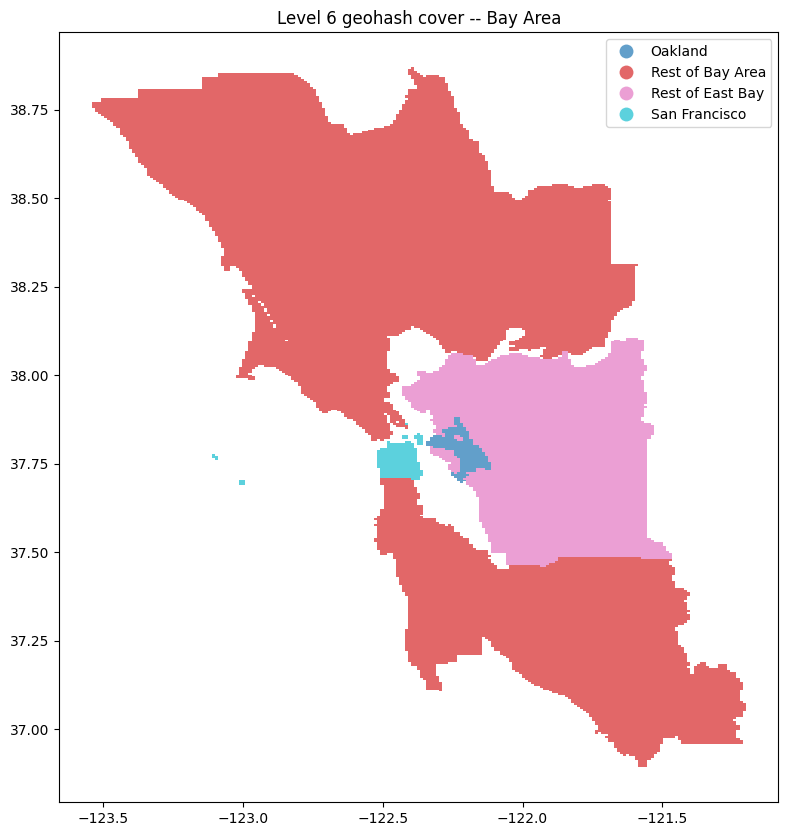

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame(level6_df.merge(level6_cell_gdf, on="geohash"), crs=WGS84).plot(
    ax=ax, column="geography", legend=True, alpha=0.7, categorical=True
)
ax.set_title("Level 6 geohash cover -- Bay Area")
plt.show()


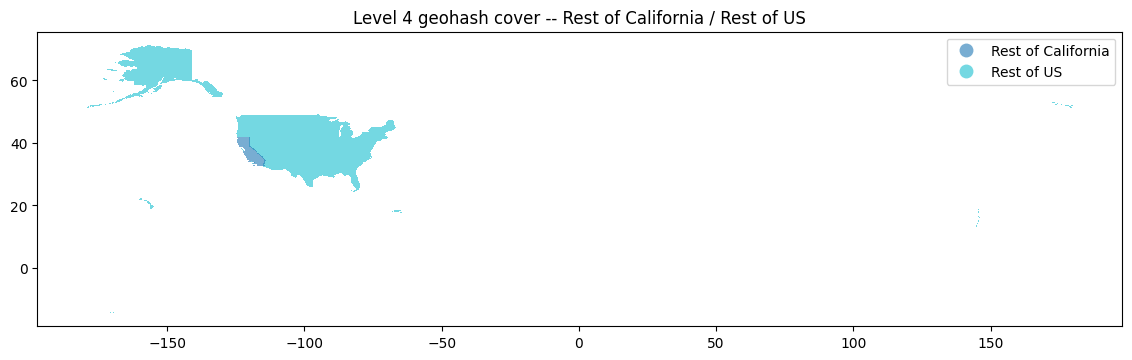

In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
gpd.GeoDataFrame(level4_df.merge(level4_cell_gdf, on="geohash"), crs=WGS84).plot(
    ax=ax, column="geography", legend=True, alpha=0.6, categorical=True
)
ax.set_title("Level 4 geohash cover -- Rest of California / Rest of US")
plt.show()


# Section 9 -- Save Outputs

Two CSV files, each with a `geohash` column and a `geography` column:
- `geohash_level6_bay_area.csv`
- `geohash_level4_rest_of_state_country.csv` (also includes an `overlap_fraction` column,
  since a geohash can appear more than once here)

In [13]:
level6_df.to_csv(LEVEL6_OUTPUT_PATH, index=False)
level4_df.to_csv(LEVEL4_OUTPUT_PATH, index=False)

print(f"Wrote {len(level6_df):,} rows to {LEVEL6_OUTPUT_PATH}")
print(f"Wrote {len(level4_df):,} rows to {LEVEL4_OUTPUT_PATH}")


Wrote 32,364 rows to /home/aniket/Programming/eddit-east-bay/data/geo/geohash/geohash_level6_bay_area.csv
Wrote 19,156 rows to /home/aniket/Programming/eddit-east-bay/data/geo/geohash/geohash_level4_rest_of_state_country.csv


# Section 10 -- Level 9 Geohash Cover for Oakland Business Corridors (BIDs)

A much finer cover (geohash precision 9, cells are roughly 5m x 5m) for the eleven Oakland
Business Improvement Districts in `data/corridors/OAK_BIDs`. These polygons are small and
disjoint, so we reuse the same grid-generation and multi-label classification helpers from
Sections 4-5 directly: grid the union of all eleven corridors at precision 9, then classify
every cell against each corridor polygon, keeping only cells whose coverage fraction is at
least `MIN_CORRIDOR_COVERAGE_FRACTION` (80%).

In [14]:
corridors_gdf = gpd.read_file(OAK_BIDS_PATH).to_crs(WGS84)
print(f"OAK BIDs: {len(corridors_gdf)} corridors")
corridors_gdf[["FID", "BID"]]


OAK BIDs: 11 corridors


,FID,BID
0,1,Downtown
1,2,Chinatown
2,3,Lake Merritt
3,4,Koreatown/Northgate
4,5,Montclair
5,6,Rockridge
6,7,Temescal/Telegraph
7,8,Fruitvale
8,9,Lakeshore
9,10,Jack London


In [15]:
corridor_layers = dict(zip(corridors_gdf["BID"], corridors_gdf["geometry"]))
corridors_union_geom = corridors_gdf.geometry.union_all()

t0 = time.time()
level9_hashes = generate_geohash_grid(corridors_union_geom, GEOHASH_PRECISION_CORRIDOR)
print(f"Generated {len(level9_hashes):,} candidate level-9 geohashes in {time.time() - t0:.1f}s")

level9_cell_gdf = geohashes_to_gdf(level9_hashes)

t0 = time.time()
level9_df = classify_multi_label(level9_cell_gdf, corridor_layers, MIN_CORRIDOR_COVERAGE_FRACTION)
print(f"Classified {len(level9_df):,} level-9 geohash/corridor rows in {time.time() - t0:.1f}s")

level9_df = level9_df.rename(columns={"geohash": "geohash9", "geography": "corridor_name", "overlap_fraction": "coverage_fraction"})
level9_df = level9_df.merge(corridors_gdf[["FID", "BID"]], left_on="corridor_name", right_on="BID")
level9_df = level9_df.rename(columns={"FID": "corridor_id"})[["corridor_id", "corridor_name", "geohash9", "coverage_fraction"]]
level9_df = level9_df.sort_values(["corridor_id", "geohash9"]).reset_index(drop=True)

level9_df["corridor_name"].value_counts()


gridding precision 9 (7 parts):   0%|          | 0/7 [00:00<?, ?it/s]

Generated 829,906 candidate level-9 geohashes in 0.7s


building cell polygons:   0%|          | 0/829906 [00:00<?, ?it/s]

/tmp/ipykernel_419925/3781018462.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cell_area = cell_gdf.set_index("geohash").geometry.area


Classified 218,259 level-9 geohash/corridor rows in 16.3s


corridor_name
Jack London            46662
Chinatown              33934
Lake Merritt           31669
Temescal/Telegraph     26386
Downtown               22939
Fruitvale              20594
Koreatown/Northgate    19473
Rockridge               6969
Laurel                  4705
Lakeshore               2481
Montclair               2447
Name: count, dtype: int64

Save the level-9 corridor cover to `data/corridors/geohash/geohash_level9_oak_bids.csv`, with
one row per (corridor, geohash9) pair that clears the 80% coverage threshold.

In [16]:
level9_df.to_csv(LEVEL9_CORRIDORS_OUTPUT_PATH, index=False)
print(f"Wrote {len(level9_df):,} rows to {LEVEL9_CORRIDORS_OUTPUT_PATH}")


Wrote 218,259 rows to /home/aniket/Programming/eddit-east-bay/data/corridors/geohash/geohash_level9_oak_bids.csv
